In [11]:
library(ncdf4) # package for netcdf manipulation
library(raster) # package for raster manipulation
library(ggplot2) # package for plotting

In [2]:
filepath <- "C:/code/CLUES/data/reanalysis-era5-land/2m_dewpoint_temperature/2021.nc"
nc_data <- nc_open(filepath)

In [3]:
lon <- ncvar_get(nc_data, "longitude")
lat <- ncvar_get(nc_data, "latitude", verbose = F)
t <- ncvar_get(nc_data, "valid_time")

In [4]:
# Read in the data from the NDVI variable and verify the dimensions of the array. 
dOI.array <- ncvar_get(nc_data, "d2m") # store the data in a 3-dimensional array
print(dim(dOI.array) )
#Other pertinent information about the NDVI variable: Lets’s see what fill value was used for missing data.
fillvalue <- ncatt_get(nc_data, "d2m", "_FillValue")
print(fillvalue)
dOI.array[dOI.array == fillvalue$value] <- NA

[1]   92   78 8760
$hasatt
[1] TRUE

$value
[1] NaN



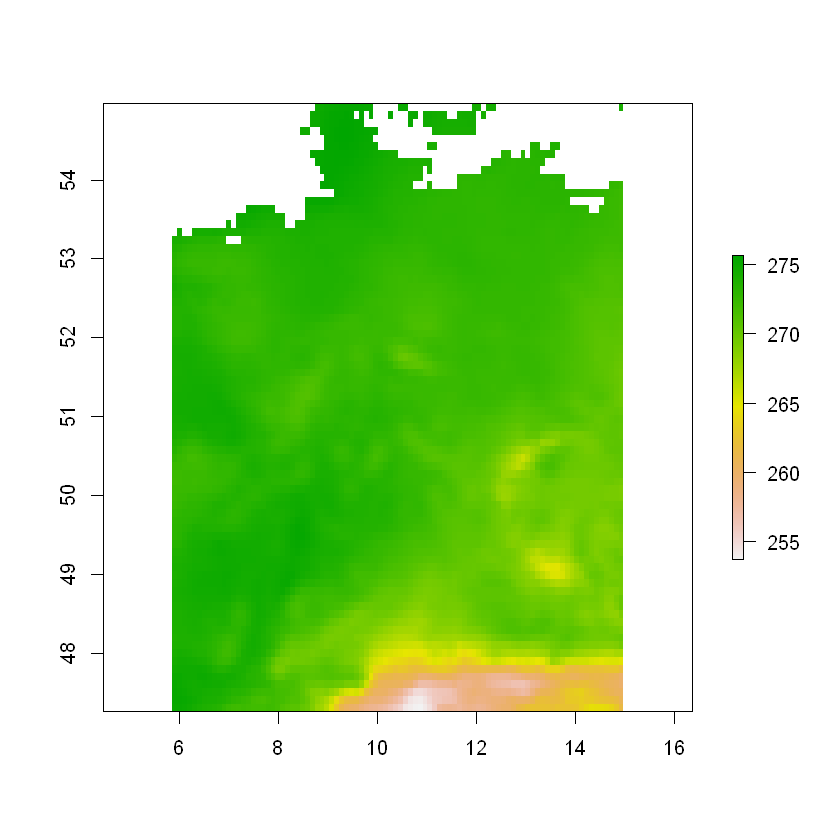

In [5]:
dOI.slice <- dOI.array[, , 1] 
r <- raster(t(dOI.slice), xmn=min(lon), xmx=max(lon), ymn=min(lat), ymx=max(lat), crs=CRS("+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs+ towgs84=0,0,0"))
plot(r)

In [6]:
# Maybe you want to get a timeseries of NDVI at a distinct location
# Convert the entire 3d array of data to a raster brick
r_brick <- brick(dOI.array, xmn=min(lat), xmx=max(lat), ymn=min(lon), ymx=max(lon), crs=CRS("+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs+ towgs84=0,0,0"))

In [35]:
# Extract timeseries at a distinct location (cell index 6)
lon_pt <- 13      # longitude of your point
lat_pt <- 52.0   # latitude of your point

# Create SpatialPoints with the same CRS as r_brick
pt <- SpatialPoints(matrix(c(lon_pt, lat_pt), ncol = 2, byrow = TRUE),
                    proj4string = CRS(projection(r_brick)))

# Try extracting; if NA, try swapped coords (handles possible x/y extent swap)
location_series <- extract(r_brick, pt, method = 'simple')

if (all(is.na(location_series))) {
  pt_swap <- SpatialPoints(matrix(c(lat_pt, lon_pt), ncol = 2, byrow = TRUE),
                           proj4string = CRS(projection(r_brick)))
  location_series <- extract(r_brick, pt_swap, method = 'simple')
  if (!all(is.na(location_series))) {
    warning("Extraction succeeded after swapping lon/lat — check raster extent creation (xmn/xmx/ymn/ymx).")
  } else {
    stop("Extraction returned NA. Check raster extent and CRS of r_brick and the point coordinates.")
  }
}

# Ensure a numeric vector (1 x nlayers -> numeric)
location_series <- as.numeric(location_series)

Warning message:
"Extraction succeeded after swapping lon/lat — check raster extent creation (xmn/xmx/ymn/ymx)."


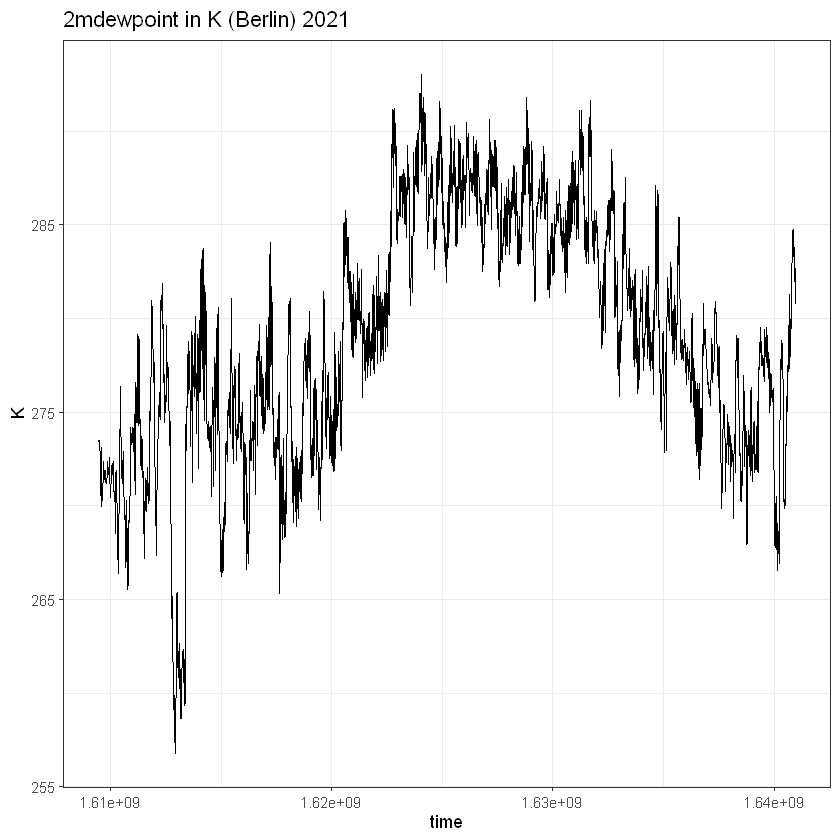

In [42]:
toolik_df <- data.frame(time= t, K=location_series)
ggplot(data=toolik_df, aes(x=time, y=K, group=1)) +
  geom_line() + # make this a line plot
  ggtitle("2mdewpoint in K (Berlin) 2021") +     # Set title
  theme_bw() # use the black and white theme

In [ ]:
# For further tutorials, see:

# https://www.nordatanet.no/en/NetCDF-in-R-from-beginner-to-pro